# Modèle Spécialisé - Prédiction d'Âge

Ce notebook implémente un modèle de deep learning spécialisé dans la prédiction de l'âge à partir de photos de visages.

**Architecture:** Transfer Learning avec EfficientNetB0
**Tâche:** Régression (prédiction d'âge continu)
**Dataset:** UTKFace (23,708 images)


## 1. Configuration et Imports


In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

# Configuration GPU
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from scipy import stats

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

# Configuration
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

# Permettre la croissance mémoire GPU
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# Seed pour reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Style des graphiques
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titlesize": 14})

TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Hyperparamètres


In [2]:
# Chemins
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data" / "UTKFace"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

# Hyperparamètres optimisés
IMG_SIZE = 128
BATCH_SIZE = 64  # Augmenté pour meilleure convergence
WARMUP_EPOCHS = 20  # Augmenté
FINETUNE_EPOCHS = 50  # Augmenté
INITIAL_LR = 5e-4  # Réduit pour stabilité
FINETUNE_LR = 1e-5

# Validation
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1

print(f"Configuration optimisée:")
print(f"  - Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Warmup epochs: {WARMUP_EPOCHS}")
print(f"  - Fine-tune epochs: {FINETUNE_EPOCHS}")
print(f"  - Initial LR: {INITIAL_LR}")

Configuration optimisée:
  - Image size: 128x128
  - Batch size: 64
  - Warmup epochs: 20
  - Fine-tune epochs: 50
  - Initial LR: 0.0005


## 3. Chargement des Données


In [3]:
def parse_utkface_filename(filepath: Path) -> dict | None:
    """Parse les métadonnées depuis le nom de fichier UTKFace."""
    try:
        name = filepath.name.split(".")[0]
        parts = name.split("_")
        if len(parts) < 1 or not parts[0].isdigit():
            return None

        age = int(parts[0])
        # Filtrer les âges aberrants
        if age < 0 or age > 116:
            return None

        return {"filepath": str(filepath), "age": age}
    except Exception:
        return None


def validate_image(filepath: str) -> bool:
    """Vérifie qu'une image est lisible."""
    try:
        with Image.open(filepath) as img:
            img.verify()
        return True
    except Exception:
        return False


# Charger toutes les images
image_paths = list(DATA_DIR.glob("*.jpg*"))
print(f"Images trouvées: {len(image_paths)}")

# Parser les métadonnées
records = []
for path in tqdm(image_paths, desc="Parsing des fichiers"):
    record = parse_utkface_filename(path)
    if record:
        records.append(record)

df = pd.DataFrame(records)
print(f"\nImages valides: {len(df)}")

Images trouvées: 23708


Parsing des fichiers: 100%|██████████| 23708/23708 [00:00<00:00, 1556305.12it/s]


Images valides: 23708


Statistiques de l'âge:
count    23708.000000
mean        33.303484
std         19.886112
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64


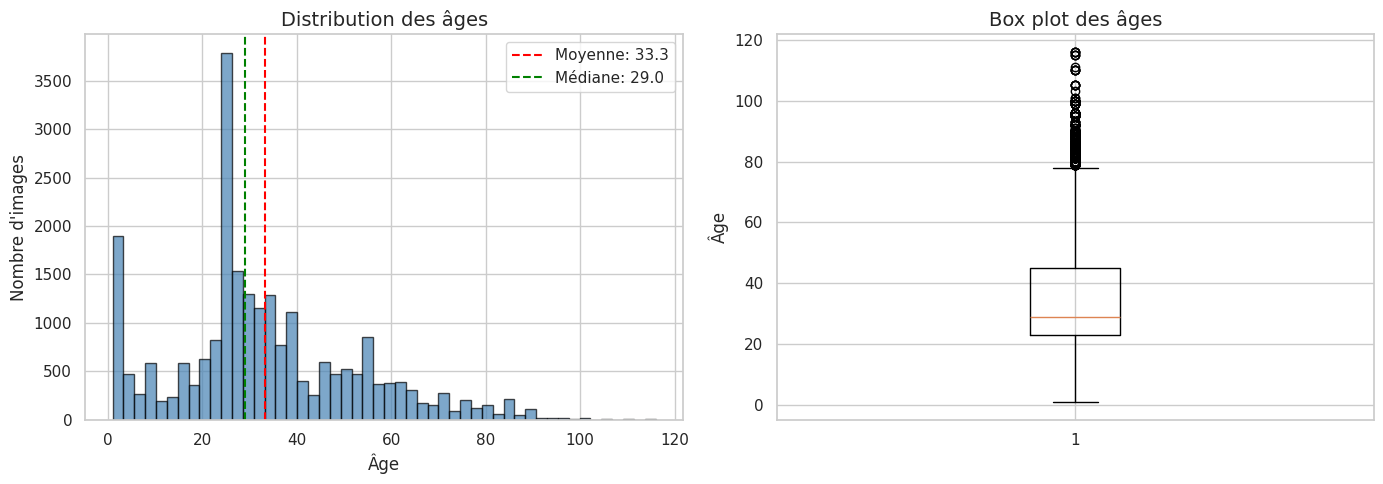

In [4]:
# Statistiques de base sur l'âge
print("Statistiques de l'âge:")
print(df["age"].describe())

# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df["age"], bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Nombre d'images")
axes[0].set_title("Distribution des âges")
axes[0].axvline(
    df["age"].mean(),
    color="red",
    linestyle="--",
    label=f'Moyenne: {df["age"].mean():.1f}',
)
axes[0].axvline(
    df["age"].median(),
    color="green",
    linestyle="--",
    label=f'Médiane: {df["age"].median():.1f}',
)
axes[0].legend()

# Box plot
axes[1].boxplot(df["age"], vert=True)
axes[1].set_ylabel("Âge")
axes[1].set_title("Box plot des âges")

plt.tight_layout()
plt.show()

## 4. Nettoyage des Données (Outliers)


In [5]:
# Supprimer les outliers extrêmes avec z-score
z_scores = np.abs(stats.zscore(df["age"]))
outliers_mask = z_scores > 3
n_outliers = outliers_mask.sum()
print(f"Outliers détectés (z-score > 3): {n_outliers}")
print(f"Âges des outliers: {df.loc[outliers_mask, 'age'].values[:10]}...")

# Garder uniquement les non-outliers
df_clean = df[~outliers_mask].copy()
print(f"\nImages après nettoyage: {len(df_clean)}")
print(f"Plage d'âge: {df_clean['age'].min()} - {df_clean['age'].max()}")

Outliers détectés (z-score > 3): 72
Âges des outliers: [100 100  99 100  96  96  96 110  95 105]...

Images après nettoyage: 23636
Plage d'âge: 1 - 92


## 5. Création des Buckets d'Âge pour Stratification


Distribution par bucket d'âge:
age_bucket
0-5      2363
6-10      855
11-15     610
16-20    1049
21-25    2760
26-30    5024
31-40    4339
41-50    2100
51-60    2211
61-70    1172
70+      1153
Name: count, dtype: int64


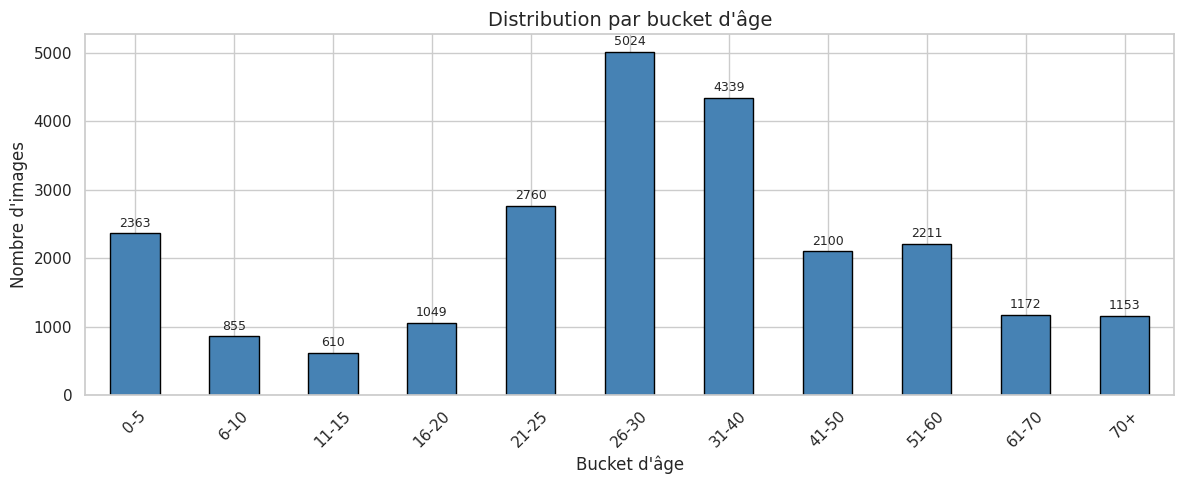

In [6]:
# Créer des buckets pour une stratification équilibrée
age_bins = [0, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 120]
age_labels = [
    "0-5",
    "6-10",
    "11-15",
    "16-20",
    "21-25",
    "26-30",
    "31-40",
    "41-50",
    "51-60",
    "61-70",
    "70+",
]
df_clean["age_bucket"] = pd.cut(df_clean["age"], bins=age_bins, labels=age_labels)

# Distribution par bucket
bucket_counts = df_clean["age_bucket"].value_counts().sort_index()
print("Distribution par bucket d'âge:")
print(bucket_counts)

# Visualisation
plt.figure(figsize=(12, 5))
bucket_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Bucket d'âge")
plt.ylabel("Nombre d'images")
plt.title("Distribution par bucket d'âge")
plt.xticks(rotation=45)
for i, v in enumerate(bucket_counts.values):
    plt.text(i, v + 100, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Split Train/Validation/Test (Stratifié)


Split des données:
  - Train: 18908 (80.0%)
  - Val: 2364 (10.0%)
  - Test: 2364 (10.0%)
Train set après oversampling: 30169 (était 18908)


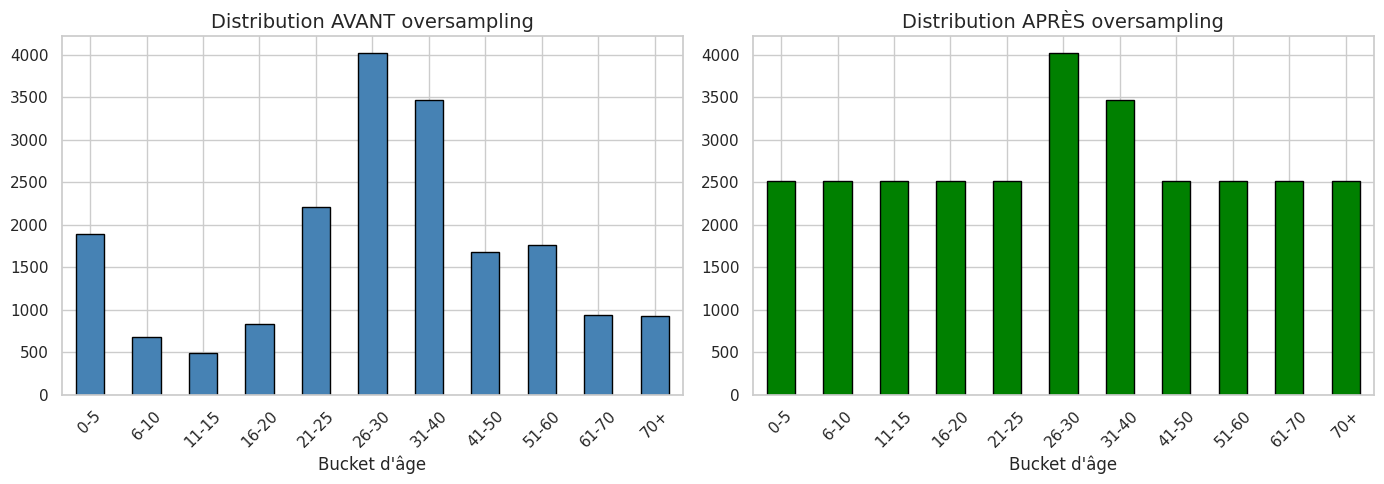

In [7]:
# Split stratifié basé sur les buckets d'âge
X = df_clean["filepath"].values
y = df_clean["age"].values

# Split train+val / test (90/10)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=df_clean["age_bucket"]
)

# Split train / val (90/10 du trainval = 81/9 du total)
# Recréer les buckets pour le stratify
trainval_buckets = pd.cut(y_trainval, bins=age_bins, labels=age_labels)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),  # Ajuster pour avoir ~10% du total
    random_state=SEED,
    stratify=trainval_buckets,
)

print(f"Split des données:")
print(f"  - Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Val: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  - Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")


# Oversampling des buckets minoritaires pour équilibrer le dataset
def oversample_minority_buckets(X, y, age_bins, age_labels, target_ratio=1.5):
    """Surééchantillonne les buckets minoritaires."""
    buckets = pd.cut(y, bins=age_bins, labels=age_labels)
    bucket_counts = pd.Series(buckets).value_counts()
    target_count = int(bucket_counts.median() * target_ratio)

    X_resampled, y_resampled = [], []

    for bucket in age_labels:
        mask = buckets == bucket
        X_bucket = X[mask]
        y_bucket = y[mask]
        current_count = len(X_bucket)

        if current_count == 0:
            continue

        if current_count < target_count:
            # Répéter les samples pour atteindre target_count
            repeats = (target_count // current_count) + 1
            X_bucket = np.tile(X_bucket, repeats)[:target_count]
            y_bucket = np.tile(y_bucket, repeats)[:target_count]

        X_resampled.extend(X_bucket)
        y_resampled.extend(y_bucket)

    # Mélanger
    indices = np.random.permutation(len(X_resampled))
    return np.array(X_resampled)[indices], np.array(y_resampled)[indices]


X_train_balanced, y_train_balanced = oversample_minority_buckets(
    X_train, y_train, age_bins, age_labels
)

print(f"Train set après oversampling: {len(X_train_balanced)} (était {len(X_train)})")

# Visualiser la nouvelle distribution
buckets_before = (
    pd.cut(y_train, bins=age_bins, labels=age_labels).value_counts().sort_index()
)
buckets_after = (
    pd.cut(y_train_balanced, bins=age_bins, labels=age_labels)
    .value_counts()
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
buckets_before.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Distribution AVANT oversampling")
axes[0].set_xlabel("Bucket d'âge")
axes[0].tick_params(axis="x", rotation=45)

buckets_after.plot(kind="bar", ax=axes[1], color="green", edgecolor="black")
axes[1].set_title("Distribution APRÈS oversampling")
axes[1].set_xlabel("Bucket d'âge")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 7. Calcul des Statistiques de Normalisation


In [8]:
# Calculer mean et std sur un échantillon du train set
def compute_normalization_stats(filepaths, sample_size=1000):
    """Calcule la moyenne et l'écart-type par canal sur un échantillon."""
    sample_paths = np.random.choice(
        filepaths, min(sample_size, len(filepaths)), replace=False
    )

    pixels = []
    for path in tqdm(sample_paths, desc="Calcul des stats"):
        img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        arr = np.array(img, dtype=np.float32) / 255.0
        pixels.append(arr)

    pixels = np.stack(pixels)
    mean = pixels.mean(axis=(0, 1, 2))
    std = pixels.std(axis=(0, 1, 2))

    return mean, std


CHANNEL_MEAN, CHANNEL_STD = compute_normalization_stats(X_train)
print(f"Mean par canal: {CHANNEL_MEAN}")
print(f"Std par canal: {CHANNEL_STD}")

Calcul des stats: 100%|██████████| 1000/1000 [00:00<00:00, 1763.63it/s]


Mean par canal: [0.6042869  0.4495175  0.38383126]
Std par canal: [0.2561747  0.22739032 0.22115591]


## 8. Pipeline de Données avec Data Augmentation


In [9]:
# Couche de data augmentation améliorée
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom((-0.2, 0.2)),
        layers.RandomTranslation(0.15, 0.15),
        layers.RandomBrightness(0.25),
        layers.RandomContrast(0.25),
    ],
    name="data_augmentation",
)


def load_and_preprocess(filepath, label):
    """Charge et prétraite une image."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label


def create_dataset(filepaths, labels, batch_size, shuffle=True, augment=False):
    """Crée un tf.data.Dataset."""
    labels = labels.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(filepaths), seed=SEED, reshuffle_each_iteration=True
        )

    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)

    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


# Créer les datasets avec les données équilibrées
train_ds = create_dataset(
    X_train_balanced, y_train_balanced, BATCH_SIZE, shuffle=True, augment=True
)
val_ds = create_dataset(X_val, y_val, BATCH_SIZE, shuffle=False, augment=False)
test_ds = create_dataset(X_test, y_test, BATCH_SIZE, shuffle=False, augment=False)

print("Datasets créés avec succès!")
print(f"  - Train batches: {len(X_train_balanced) // BATCH_SIZE}")
print(f"  - Val batches: {len(X_val) // BATCH_SIZE}")
print(f"  - Test batches: {len(X_test) // BATCH_SIZE}")

I0000 00:00:1768738902.396335   57416 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4081 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Datasets créés avec succès!
  - Train batches: 471
  - Val batches: 36
  - Test batches: 36


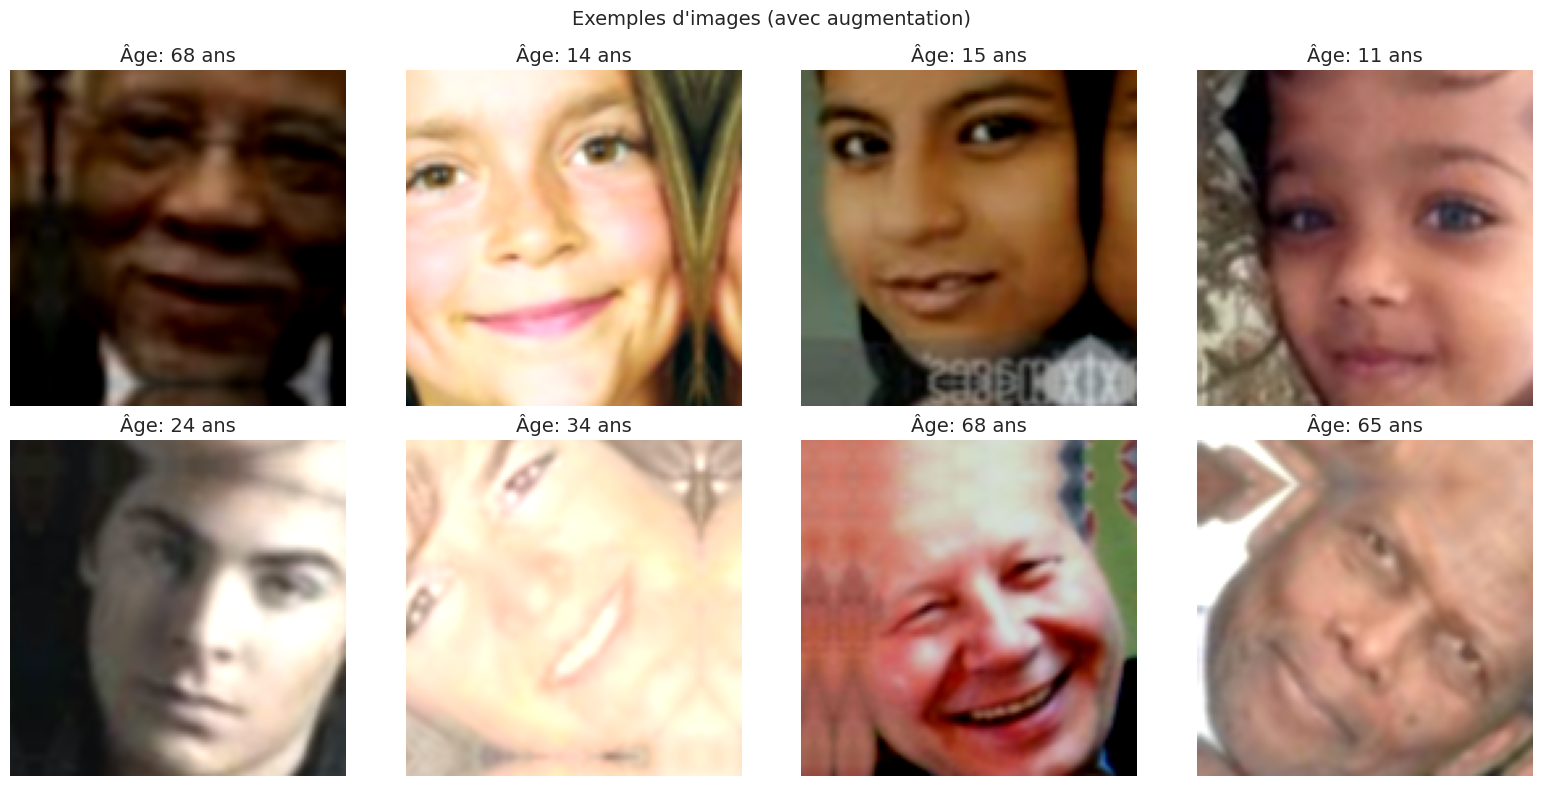

In [10]:
# Visualiser quelques exemples avec augmentation
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for images, ages in train_ds.take(1):
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            # Images sont en [0, 255], normaliser pour affichage
            img = images[i].numpy() / 255.0
            img = np.clip(img, 0, 1)
            ax.imshow(img)
            ax.set_title(f"Âge: {ages[i].numpy():.0f} ans")
            ax.axis("off")
        else:
            ax.axis("off")

plt.suptitle("Exemples d'images (avec augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Construction du Modèle


In [11]:
def build_age_model_v2(img_size: int, trainable_backbone: bool = False) -> Model:
    """Modèle amélioré avec double pooling et régularisation."""

    inputs = layers.Input(shape=(img_size, img_size, 3), name="input_image")

    # Backbone EfficientNetB0
    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3),
        pooling=None,
    )
    backbone.trainable = trainable_backbone

    x = backbone(inputs)

    # Double pooling (GAP + GMP) pour capturer plus d'informations
    gap = layers.GlobalAveragePooling2D(name="gap")(x)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(x)
    concat = layers.Concatenate(name="concat_pool")([gap, gmp])

    # Head de régression avec régularisation L2
    x = layers.Dense(
        512, kernel_regularizer=keras.regularizers.l2(1e-4), name="dense_1"
    )(concat)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Activation("relu", name="relu_1")(x)
    x = layers.Dropout(0.5, name="dropout_1")(x)

    x = layers.Dense(
        256, kernel_regularizer=keras.regularizers.l2(1e-4), name="dense_2"
    )(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Activation("relu", name="relu_2")(x)
    x = layers.Dropout(0.4, name="dropout_2")(x)

    x = layers.Dense(
        64, kernel_regularizer=keras.regularizers.l2(1e-4), name="dense_3"
    )(x)
    x = layers.BatchNormalization(name="bn_3")(x)
    x = layers.Activation("relu", name="relu_3")(x)
    x = layers.Dropout(0.3, name="dropout_3")(x)

    outputs = layers.Dense(1, activation="linear", name="age_output")(x)

    model = Model(inputs, outputs, name="AgeModel_EfficientNetB0_v2")
    return model, backbone


# Construire le modèle amélioré
model, backbone = build_age_model_v2(IMG_SIZE, trainable_backbone=False)
model.summary()

Model: "AgeModel_EfficientNetB0_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 4, 4,      │  4,049,571 │ input_image[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp                 │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_pool         │ (None, 2560)      │          0 │ gap[0][0],        │
│ (Concatenate)       │                   │            │ gmp[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │  1,311,232 │ concat_pool[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 512)       │      2,048 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_1 (Activation) │ (None, 512)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ relu_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_2 (Activation) │ (None, 256)       │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ relu_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │     16,448 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_3 (Activation) │ (None, 64)        │          0 │ bn_3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ relu_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,511,972 (21.03 MB)

 Trainable params: 1,460,737 (5.57 MB)

 Non-trainable params: 4,051,235 (15.45 MB)

## 10. Métriques Personnalisées


In [12]:
# Métrique R² (coefficient de détermination)
# Note: Pour Keras 3, on utilise tf.keras.utils.register_keras_serializable
try:
    from keras.saving import register_keras_serializable
except (ImportError, AttributeError):
    from tensorflow.keras.utils import register_keras_serializable


@register_keras_serializable()
class R2Score(keras.metrics.Metric):
    def __init__(self, name="r2_score", **kwargs):
        super().__init__(name=name, **kwargs)
        self.ss_res = self.add_weight(name="ss_res", initializer="zeros")
        self.ss_tot = self.add_weight(name="ss_tot", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")
        self.y_sum = self.add_weight(name="y_sum", initializer="zeros")
        self.y_sq_sum = self.add_weight(name="y_sq_sum", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.squeeze(y_true), tf.float32)
        y_pred = tf.cast(tf.squeeze(y_pred), tf.float32)

        self.ss_res.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))
        self.y_sum.assign_add(tf.reduce_sum(y_true))
        self.y_sq_sum.assign_add(tf.reduce_sum(tf.square(y_true)))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        y_mean = self.y_sum / tf.maximum(self.count, 1.0)
        ss_tot = (
            self.y_sq_sum - 2 * y_mean * self.y_sum + self.count * tf.square(y_mean)
        )
        return 1.0 - (self.ss_res / tf.maximum(ss_tot, 1e-7))

    def reset_state(self):
        self.ss_res.assign(0.0)
        self.ss_tot.assign(0.0)
        self.count.assign(0.0)
        self.y_sum.assign(0.0)
        self.y_sq_sum.assign(0.0)


print("Métrique R2Score définie avec succès!")

Métrique R2Score définie avec succès!


## 11. Phase 1: Warmup (Backbone Gelé)


In [13]:
from tensorflow.keras.losses import Huber

# Calculer le nombre de steps
steps_per_epoch = len(X_train_balanced) // BATCH_SIZE
total_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

# Learning rate schedule avec cosine decay
warmup_lr_schedule = CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=total_warmup_steps,
    alpha=0.1,
)

# Compiler avec Huber Loss (robuste aux outliers)
model.compile(
    optimizer=Adam(learning_rate=warmup_lr_schedule),
    loss=Huber(delta=5.0),
    metrics=["mae", "mse"],
)

# Callbacks - SANS ReduceLROnPlateau (incompatible avec CosineDecay)
warmup_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_mae", patience=12, restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "age_warmup_best.keras"),
        monitor="val_mae",
        save_best_only=True,
        verbose=1,
    ),
]

print(f"Phase 1: Warmup ({WARMUP_EPOCHS} epochs, backbone gelé)")
print(
    f"Paramètres entraînables: {sum([tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]):,}"
)
print(f"Loss: Huber (delta=5.0)")
print(f"LR Schedule: CosineDecay ({INITIAL_LR} -> {INITIAL_LR * 0.1})")

Phase 1: Warmup (20 epochs, backbone gelé)
Paramètres entraînables: 1,460,737
Loss: Huber (delta=5.0)
LR Schedule: CosineDecay (0.0005 -> 5e-05)


In [14]:
# Entraînement Phase 1
warmup_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=warmup_callbacks,
    verbose=1,
)

Epoch 1/20


2026-01-18 13:22:00.400719: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:22:00.486856: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:22:00.950396: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:22:01.041243: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:22:01.495124: E external/local_xla/xla/stream_

471/472 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 147.9470 - mae: 32.0094 - mse: 1528.2215

2026-01-18 13:22:28.496616: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:22:28.581751: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:22:28.971305: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:22:29.061085: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:22:29.492912: E external/local_xla/xla/stream_

472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 147.9203 - mae: 32.0040 - mse: 1527.8272

2026-01-18 13:22:44.724445: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:22:44.810145: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:22:45.240540: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:22:45.331185: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:22:45.419849: E external/local_xla/xla/stream_


Epoch 1: val_mae improved from None to 19.82962, saving model to /home/optimalako/Projet/SAE/artifacts/age_warmup_best.keras

Epoch 1: finished saving model to /home/optimalako/Projet/SAE/artifacts/age_warmup_best.keras
472/472 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - loss: 135.3464 - mae: 29.4695 - mse: 1342.1149 - val_loss: 87.3253 - val_mae: 19.8296 - val_mse: 623.7561
Epoch 2/20
471/472 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 89.1226 - mae: 20.0967 - mse: 713.2621
Epoch 2: val_mae improved from 19.82962 to 9.38243, saving model to /home/optimalako/Projet/SAE/artifacts/age_warmup_best.keras

Epoch 2: finished saving model to /home/optimalako/Projet/SAE/artifacts/age_warmup_best.keras
472/472 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - loss: 74.2119 - mae: 17.0594 - mse: 543.5303 - val_loss: 36.6147 - val_mae: 9.3824 - val_mse: 167.7365
Epoch 3/20
471/472 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 49.8445 - mae: 12.1056 - mse: 286.2493
Epoch 3: val_mae did not improve from 9.38243
472/472 ━━━

## 12. Phase 2: Fine-tuning (Backbone Partiellement Dégelé)


In [15]:
# Dégeler les dernières couches du backbone
backbone.trainable = True

# Geler les premières couches (garder les features de bas niveau)
# EfficientNetB0 a environ 237 layers, on dégèle les 50 derniers
freeze_until = len(backbone.layers) - 50
for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

trainable_count = sum(
    [tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]
)
print(f"Phase 2: Fine-tuning ({FINETUNE_EPOCHS} epochs)")
print(f"Couches dégelées: {len(backbone.layers) - freeze_until}/{len(backbone.layers)}")
print(f"Paramètres entraînables: {trainable_count:,}")

Phase 2: Fine-tuning (50 epochs)
Couches dégelées: 50/238
Paramètres entraînables: 3,987,601


In [16]:
# Learning rate plus faible pour le fine-tuning
total_finetune_steps = steps_per_epoch * FINETUNE_EPOCHS

finetune_lr_schedule = CosineDecay(
    initial_learning_rate=FINETUNE_LR, decay_steps=total_finetune_steps, alpha=0.01
)

# Recompiler avec Huber Loss
model.compile(
    optimizer=Adam(learning_rate=finetune_lr_schedule),
    loss=Huber(delta=5.0),
    metrics=["mae", "mse"],
)

# Callbacks - SANS ReduceLROnPlateau
finetune_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_mae", patience=15, restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "age_model_best.keras"),
        monitor="val_mae",
        save_best_only=True,
        verbose=1,
    ),
]

print(f"LR Schedule: CosineDecay ({FINETUNE_LR} -> {FINETUNE_LR * 0.01})")

LR Schedule: CosineDecay (1e-05 -> 1.0000000000000001e-07)


In [17]:
# Entraînement Phase 2
finetune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=finetune_callbacks,
    verbose=1,
)

Epoch 1/50
470/472 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 59.5005 - mae: 14.0831 - mse: 371.7859

2026-01-18 13:28:12.647815: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:28:12.735146: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 59.4808 - mae: 14.0791 - mse: 371.5842
Epoch 1: val_mae improved from None to 9.34892, saving model to /home/optimalako/Projet/SAE/artifacts/age_model_best.keras

Epoch 1: finished saving model to /home/optimalako/Projet/SAE/artifacts/age_model_best.keras
472/472 ━━━━━━━━━━━━━━━━━━━━ 52s 70ms/step - loss: 54.8597 - mae: 13.1439 - mse: 324.1840 - val_loss: 36.4698 - val_mae: 9.3489 - val_mse: 164.6591
Epoch 2/50
471/472 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 47.7453 - mae: 11.6782 - mse: 260.9002
Epoch 2: val_mae improved from 9.34892 to 8.77201, saving model to /home/optimalako/Projet/SAE/artifacts/age_model_best.keras

Epoch 2: finished saving model to /home/optimalako/Projet/SAE/artifacts/age_model_best.keras
472/472 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - loss: 46.8418 - mae: 11.5032 - mse: 249.9472 - val_loss: 33.7858 - val_mae: 8.7720 - val_mse: 147.0238
Epoch 3/50
471/472 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 43.7596 - mae: 10

## 13. Visualisation de l'Entraînement


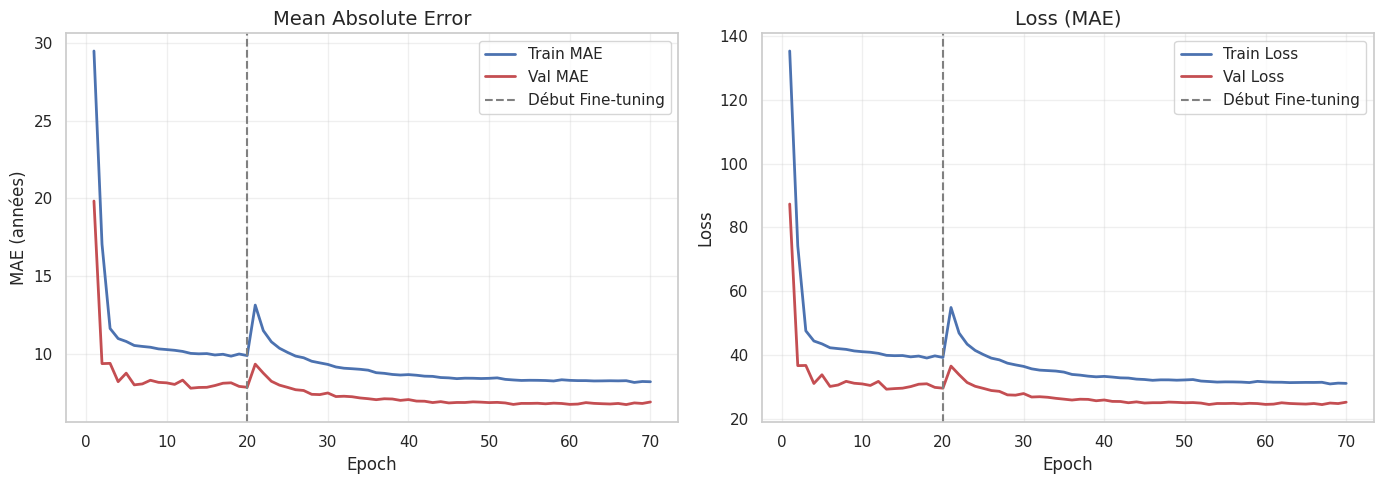


Meilleur Val MAE: 6.75 années (epoch 67)


In [18]:
def plot_training_history(warmup_hist, finetune_hist):
    """Visualise l'historique d'entraînement des deux phases."""
    # Combiner les historiques
    combined_mae = warmup_hist.history["mae"] + finetune_hist.history["mae"]
    combined_val_mae = warmup_hist.history["val_mae"] + finetune_hist.history["val_mae"]
    combined_loss = warmup_hist.history["loss"] + finetune_hist.history["loss"]
    combined_val_loss = (
        warmup_hist.history["val_loss"] + finetune_hist.history["val_loss"]
    )

    epochs = range(1, len(combined_mae) + 1)
    warmup_end = len(warmup_hist.history["mae"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # MAE
    axes[0].plot(epochs, combined_mae, "b-", label="Train MAE", linewidth=2)
    axes[0].plot(epochs, combined_val_mae, "r-", label="Val MAE", linewidth=2)
    axes[0].axvline(
        x=warmup_end, color="gray", linestyle="--", label="Début Fine-tuning"
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MAE (années)")
    axes[0].set_title("Mean Absolute Error")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs, combined_loss, "b-", label="Train Loss", linewidth=2)
    axes[1].plot(epochs, combined_val_loss, "r-", label="Val Loss", linewidth=2)
    axes[1].axvline(
        x=warmup_end, color="gray", linestyle="--", label="Début Fine-tuning"
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("Loss (MAE)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "age_training_history.png", dpi=150)
    plt.show()

    # Meilleurs scores
    best_val_mae = min(combined_val_mae)
    best_epoch = combined_val_mae.index(best_val_mae) + 1
    print(f"\nMeilleur Val MAE: {best_val_mae:.2f} années (epoch {best_epoch})")


plot_training_history(warmup_history, finetune_history)

## 14. Évaluation sur le Test Set


In [19]:
# Charger le meilleur modèle
best_model = keras.models.load_model(ARTIFACTS_DIR / "age_model_best.keras")

# Évaluation
test_results = best_model.evaluate(test_ds, verbose=1)
print(f"\nRésultats sur le test set:")
print(f"  - Loss (MAE): {test_results[0]:.2f} années")
print(f"  - MAE: {test_results[1]:.2f} années")
print(f"  - MSE: {test_results[2]:.2f}")
print(f"  - RMSE: {np.sqrt(test_results[2]):.2f} années")

37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 6.8134 - mae: 6.9953 - mse: 95.4676

Résultats sur le test set:
  - Loss (MAE): 6.81 années
  - MAE: 7.00 années
  - MSE: 95.47
  - RMSE: 9.77 années


In [20]:
# Prédictions détaillées
y_pred = best_model.predict(test_ds, verbose=1).flatten()
y_true = y_test

# Calcul des métriques
mae = np.mean(np.abs(y_true - y_pred))
mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)

# R² score
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"\nMétriques détaillées:")
print(f"  - MAE: {mae:.2f} années")
print(f"  - RMSE: {rmse:.2f} années")
print(f"  - R² Score: {r2:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step

Métriques détaillées:
  - MAE: 7.00 années
  - RMSE: 9.77 années
  - R² Score: 0.7503


## 15. Analyse des Erreurs


In [21]:
# Créer un DataFrame avec les résultats
results_df = pd.DataFrame(
    {
        "true_age": y_true,
        "predicted_age": y_pred,
        "error": y_pred - y_true,
        "abs_error": np.abs(y_pred - y_true),
    }
)
results_df["age_bucket"] = pd.cut(
    results_df["true_age"], bins=age_bins, labels=age_labels
)

# Erreur par bucket d'âge
error_by_bucket = (
    results_df.groupby("age_bucket")
    .agg({"abs_error": ["mean", "median", "std", "count"]})
    .round(2)
)
error_by_bucket.columns = ["MAE", "Médiane", "Std", "Count"]
print("Erreur par tranche d'âge:")
display(error_by_bucket)

Erreur par tranche d'âge:


,MAE,Médiane,Std,Count
age_bucket,,,,
0-5,3.17,1.09,6.62,236
6-10,5.61,3.30,6.97,86
11-15,6.20,3.50,7.63,61
16-20,6.60,5.06,7.44,105
21-25,4.67,3.22,4.85,276
26-30,6.22,4.02,6.33,503
31-40,8.51,7.76,6.02,434
41-50,9.65,8.46,6.49,210
51-60,9.69,7.81,7.84,221


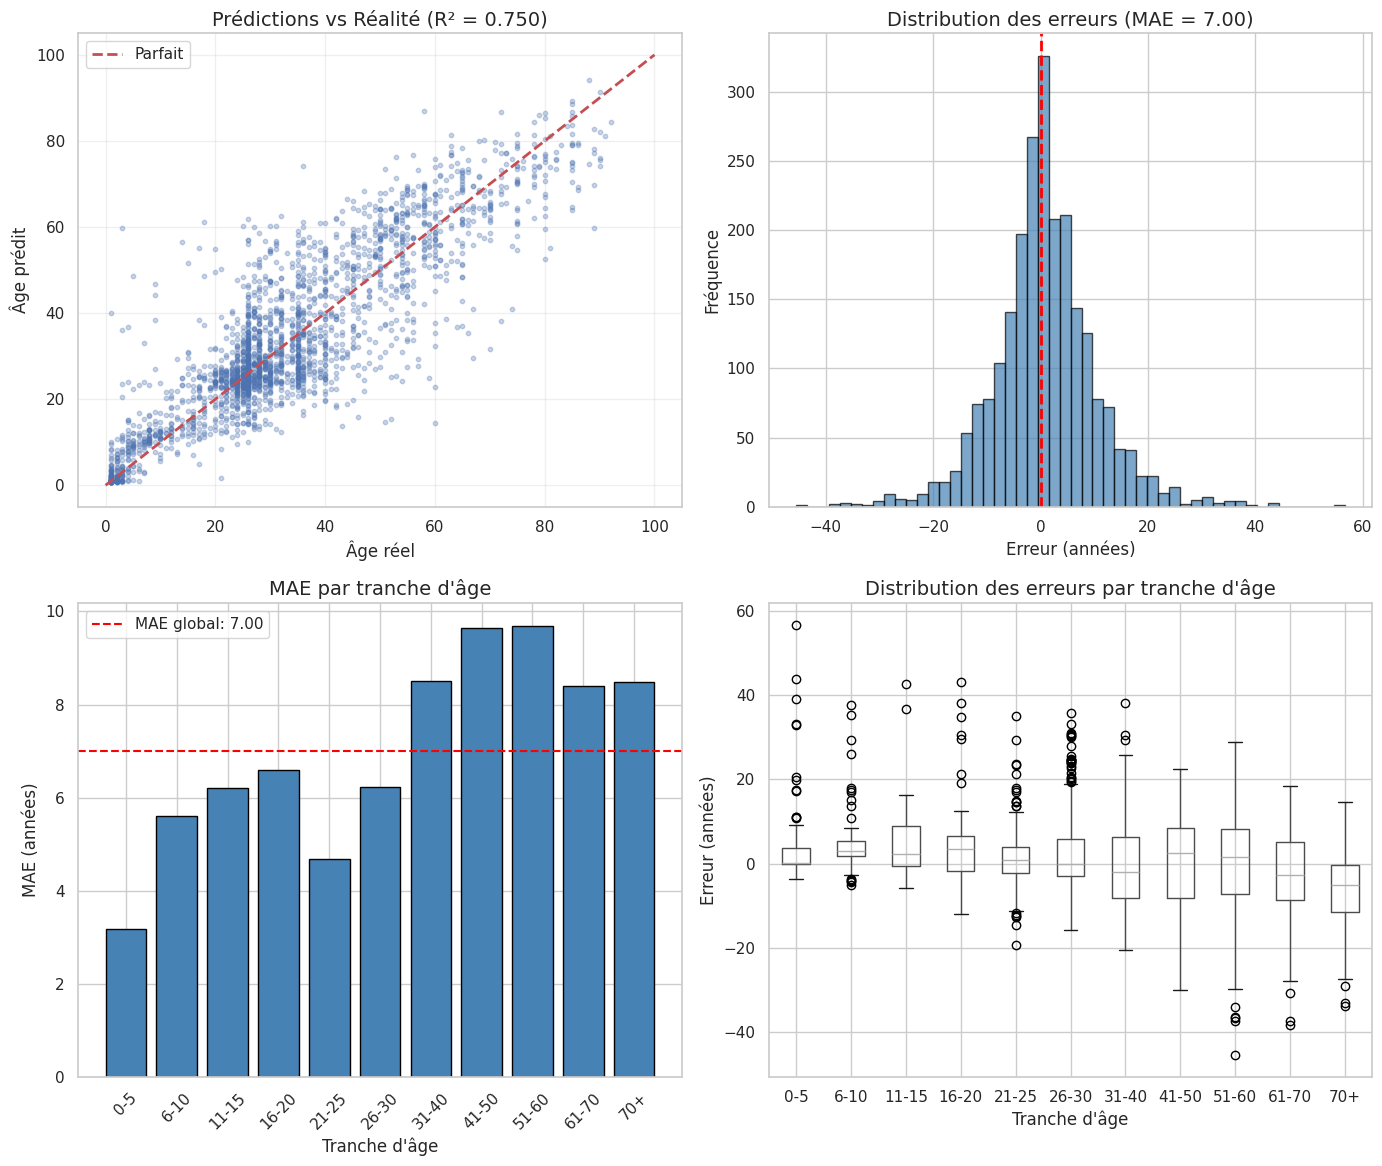

In [22]:
# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Scatter plot: Prédit vs Réel
axes[0, 0].scatter(y_true, y_pred, alpha=0.3, s=10)
axes[0, 0].plot([0, 100], [0, 100], "r--", linewidth=2, label="Parfait")
axes[0, 0].set_xlabel("Âge réel")
axes[0, 0].set_ylabel("Âge prédit")
axes[0, 0].set_title(f"Prédictions vs Réalité (R² = {r2:.3f})")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribution des erreurs
axes[0, 1].hist(
    results_df["error"], bins=50, edgecolor="black", alpha=0.7, color="steelblue"
)
axes[0, 1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[0, 1].set_xlabel("Erreur (années)")
axes[0, 1].set_ylabel("Fréquence")
axes[0, 1].set_title(f"Distribution des erreurs (MAE = {mae:.2f})")

# 3. MAE par bucket
bucket_mae = results_df.groupby("age_bucket")["abs_error"].mean()
axes[1, 0].bar(
    range(len(bucket_mae)), bucket_mae.values, color="steelblue", edgecolor="black"
)
axes[1, 0].set_xticks(range(len(bucket_mae)))
axes[1, 0].set_xticklabels(bucket_mae.index, rotation=45)
axes[1, 0].set_xlabel("Tranche d'âge")
axes[1, 0].set_ylabel("MAE (années)")
axes[1, 0].set_title("MAE par tranche d'âge")
axes[1, 0].axhline(mae, color="red", linestyle="--", label=f"MAE global: {mae:.2f}")
axes[1, 0].legend()

# 4. Box plot des erreurs par bucket
results_df.boxplot(column="error", by="age_bucket", ax=axes[1, 1])
axes[1, 1].set_xlabel("Tranche d'âge")
axes[1, 1].set_ylabel("Erreur (années)")
axes[1, 1].set_title("Distribution des erreurs par tranche d'âge")
plt.suptitle("")  # Supprimer le titre automatique

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "age_error_analysis.png", dpi=150)
plt.show()

## 16. Exemples de Prédictions


Calcul des métriques avec TTA...


TTA predictions:   0%|          | 0/200 [00:00<?, ?it/s]2026-01-18 13:43:18.103357: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:43:18.189988: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:43:18.620267: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 13:43:18.707738: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
TTA 


Comparaison (sur 200 samples):
  - MAE sans TTA: 6.80 années
  - MAE avec TTA: 6.64 années
  - Amélioration: 0.16 années


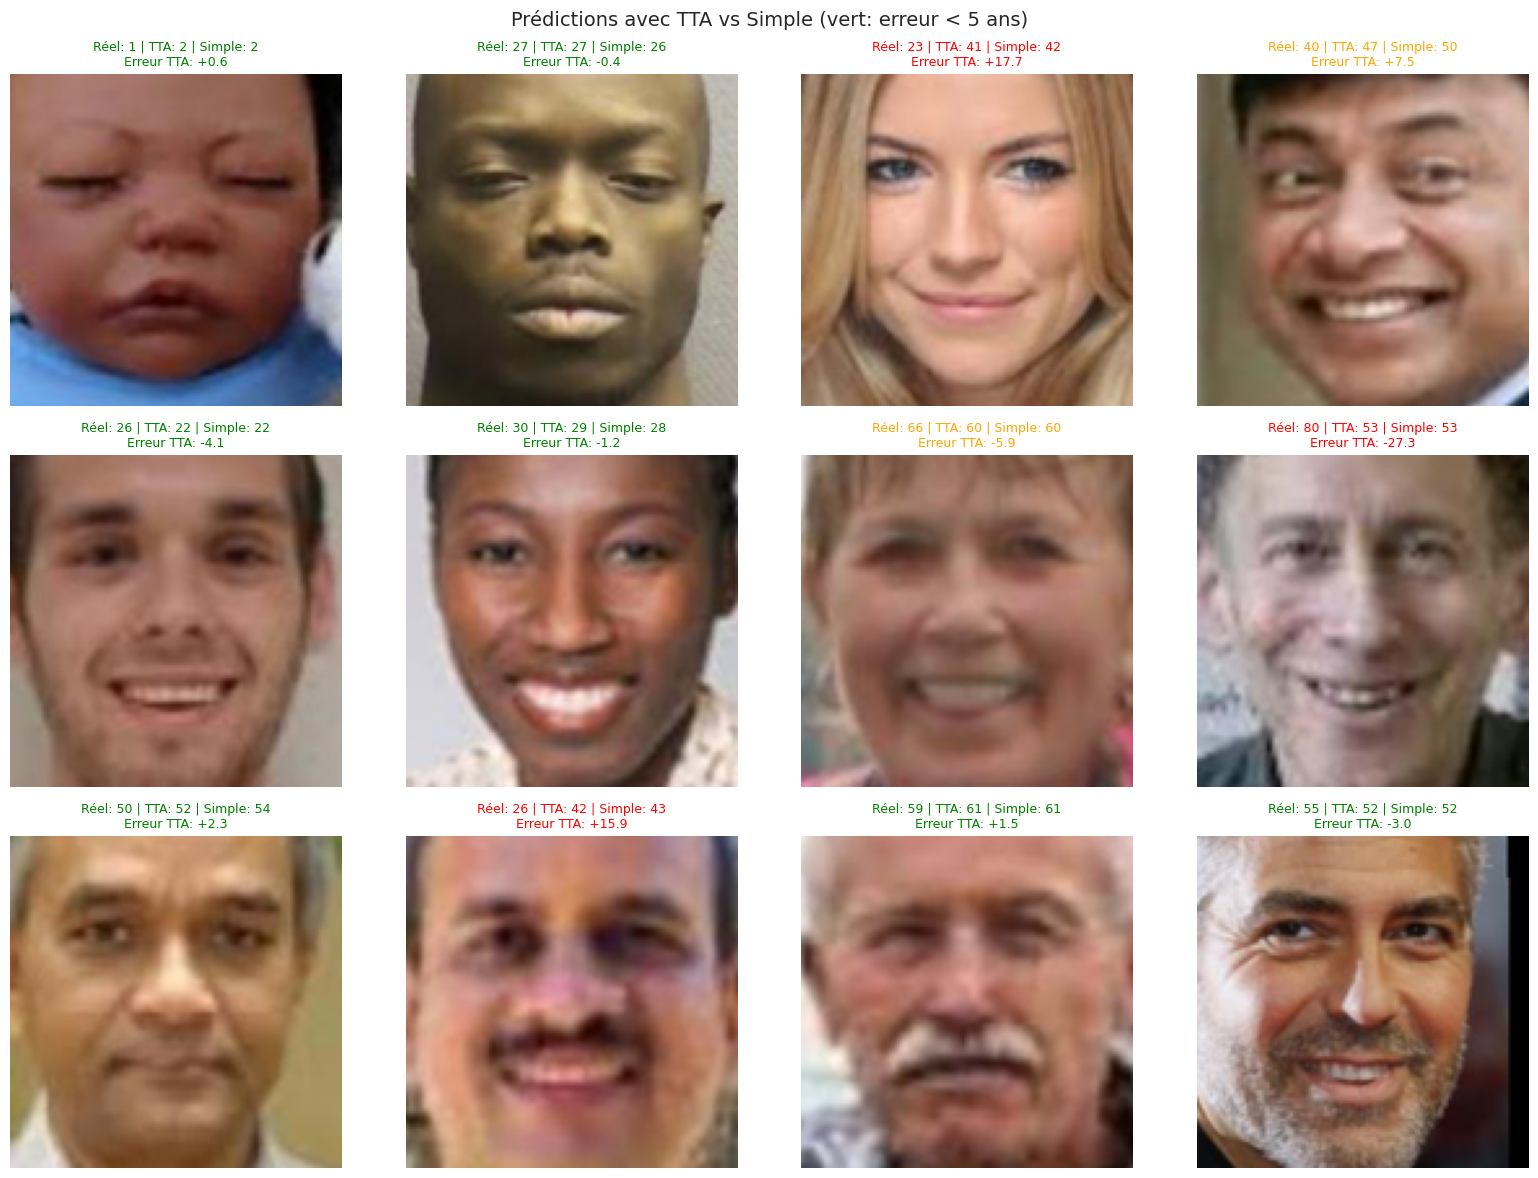

In [23]:
# Test Time Augmentation pour améliorer les prédictions
from scipy.ndimage import rotate as scipy_rotate


def predict_with_tta(model, image_array, n_augmentations=5):
    """Prédiction avec Test Time Augmentation."""
    predictions = []

    # Prédiction originale
    pred = model.predict(image_array[np.newaxis, ...], verbose=0)[0, 0]
    predictions.append(pred)

    # Flip horizontal
    flipped = np.fliplr(image_array)
    pred = model.predict(flipped[np.newaxis, ...], verbose=0)[0, 0]
    predictions.append(pred)

    # Légères variations de luminosité
    for factor in [0.9, 1.1]:
        adjusted = np.clip(image_array * factor, 0, 255)
        pred = model.predict(adjusted[np.newaxis, ...], verbose=0)[0, 0]
        predictions.append(pred)

    return np.mean(predictions)


def show_predictions_with_tta(model, filepaths, true_ages, n_samples=12):
    """Affiche les prédictions avec et sans TTA."""
    indices = np.random.choice(len(filepaths), n_samples, replace=False)
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))

    for idx, ax in zip(indices, axes.flat):
        img = Image.open(filepaths[idx]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img, dtype=np.float32)

        # Prédiction avec TTA
        pred_tta = predict_with_tta(model, img_array)
        # Prédiction simple
        pred_simple = model.predict(img_array[np.newaxis, ...], verbose=0)[0, 0]

        true = true_ages[idx]
        error_tta = pred_tta - true

        ax.imshow(img_array.astype(np.uint8))
        color = (
            "green"
            if abs(error_tta) < 5
            else ("orange" if abs(error_tta) < 10 else "red")
        )
        ax.set_title(
            f"Réel: {true:.0f} | TTA: {pred_tta:.0f} | Simple: {pred_simple:.0f}\nErreur TTA: {error_tta:+.1f}",
            color=color,
            fontsize=9,
        )
        ax.axis("off")

    plt.suptitle("Prédictions avec TTA vs Simple (vert: erreur < 5 ans)", fontsize=14)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "age_predictions_tta.png", dpi=150)
    plt.show()


# Comparer les métriques avec et sans TTA
print("Calcul des métriques avec TTA...")
y_pred_tta = []
for i, filepath in enumerate(
    tqdm(X_test[:200], desc="TTA predictions")
):  # Limité pour vitesse
    img = Image.open(filepath).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img, dtype=np.float32)
    pred = predict_with_tta(best_model, img_array)
    y_pred_tta.append(pred)

y_pred_tta = np.array(y_pred_tta)
mae_tta = np.mean(np.abs(y_test[:200] - y_pred_tta))
mae_simple = np.mean(np.abs(y_test[:200] - y_pred[:200]))

print(f"\nComparaison (sur 200 samples):")
print(f"  - MAE sans TTA: {mae_simple:.2f} années")
print(f"  - MAE avec TTA: {mae_tta:.2f} années")
print(f"  - Amélioration: {mae_simple - mae_tta:.2f} années")

show_predictions_with_tta(best_model, X_test, y_test)

## 17. Sauvegarde du Modèle Final


In [24]:
# Sauvegarder le modèle final
final_model_path = ARTIFACTS_DIR / "age_model_final.keras"
best_model.save(final_model_path)
print(f"Modèle sauvegardé: {final_model_path}")

# Sauvegarder les statistiques de normalisation
norm_stats = {
    "channel_mean": CHANNEL_MEAN.tolist(),
    "channel_std": CHANNEL_STD.tolist(),
    "img_size": IMG_SIZE,
}

import json

with open(ARTIFACTS_DIR / "age_model_norm_stats.json", "w") as f:
    json.dump(norm_stats, f, indent=2)
print(f"Stats de normalisation sauvegardées")

Modèle sauvegardé: /home/optimalako/Projet/SAE/artifacts/age_model_final.keras
Stats de normalisation sauvegardées


In [25]:
# Conversion en TFLite pour mobile
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = ARTIFACTS_DIR / "age_model.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"Modèle TFLite sauvegardé: {tflite_path}")
print(f"Taille: {tflite_path.stat().st_size / 1024 / 1024:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpyzorhuxc/assets


INFO:tensorflow:Assets written to: /tmp/tmpyzorhuxc/assets


Saved artifact at '/tmp/tmpyzorhuxc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132385986400656: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132385986397008: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132385927981456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132385927982224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132385927982416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132385927981840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132385927984912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132385927983376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132385927983952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132385927984528: TensorSpec(shape=(), dtype=tf.resource, name=None)

W0000 00:00:1768740252.566737   57416 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1768740252.566758   57416 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1768740252.673440   57416 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


## 18. Résumé des Performances


In [26]:
print("=" * 60)
print("RÉSUMÉ DU MODÈLE DE PRÉDICTION D'ÂGE")
print("=" * 60)
print(f"\nArchitecture: EfficientNetB0 + Dense Head")
print(f"Input size: {IMG_SIZE}x{IMG_SIZE}x3")
print(
    f"Dataset: {len(df_clean)} images (train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)})"
)
print(f"\nPerformances sur le test set:")
print(f"  - MAE: {mae:.2f} années")
print(f"  - RMSE: {rmse:.2f} années")
print(f"  - R² Score: {r2:.4f}")
print(f"\nFichiers sauvegardés:")
print(f"  - {final_model_path}")
print(f"  - {tflite_path}")
print("=" * 60)

RÉSUMÉ DU MODÈLE DE PRÉDICTION D'ÂGE

Architecture: EfficientNetB0 + Dense Head
Input size: 128x128x3
Dataset: 23636 images (train: 18908, val: 2364, test: 2364)

Performances sur le test set:
  - MAE: 7.00 années
  - RMSE: 9.77 années
  - R² Score: 0.7503

Fichiers sauvegardés:
  - /home/optimalako/Projet/SAE/artifacts/age_model_final.keras
  - /home/optimalako/Projet/SAE/artifacts/age_model.tflite


In [27]:
import os
import warnings

warnings.filterwarnings("ignore")

# Configuration GPU
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from scipy import stats

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

# Configuration
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

# Seed pour reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Style des graphiques
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titlesize": 14})

print("Imports OK!")

TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Imports OK!
